# ML Assignment – Manufacturing Downtime

Context: Predict monthly machine DowntimeHours and identify operational drivers in a manufacturing plant.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")


In [ ]:
data = pd.read_csv(r"manufacturing_downtime.csv")
data.head()


,MachineID,Age,OperatingHours,Temperature,VibrationLevel,Pressure,MaintenanceHours,Failures,ShiftPattern,OperatorSkill,EnergyConsumption,DowntimeHours
0,M100000,8.2,435.0,49.8,2.002,8.15,1.5,3,Day,Medium,1177.4,5.81
1,M100001,2.8,496.4,77.8,3.242,7.61,0.0,3,Night,Medium,1352.9,6.96
2,M100002,10.0,294.9,67.4,1.694,10.00,4.3,0,Rotational,Low,1187.0,3.19
3,M100003,10.8,395.7,61.4,2.322,9.73,3.5,2,Night,High,1160.0,4.18
4,M100004,0.0,490.5,65.2,2.939,6.16,2.9,0,Rotational,Medium,1225.4,4.13


In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MachineID          10000 non-null  object 
 1   Age                10000 non-null  float64
 2   OperatingHours     10000 non-null  float64
 3   Temperature        9700 non-null   float64
 4   VibrationLevel     9700 non-null   float64
 5   Pressure           10000 non-null  float64
 6   MaintenanceHours   9800 non-null   float64
 7   Failures           10000 non-null  int64  
 8   ShiftPattern       9900 non-null   object 
 9   OperatorSkill      9800 non-null   object 
 10  EnergyConsumption  9800 non-null   float64
 11  DowntimeHours      10000 non-null  float64
dtypes: float64(8), int64(1), object(3)
memory usage: 937.6+ KB


In [ ]:
data.isnull().sum()


MachineID              0
Age                    0
OperatingHours         0
Temperature          300
VibrationLevel       300
Pressure               0
MaintenanceHours     200
Failures               0
ShiftPattern         100
OperatorSkill        200
EnergyConsumption    200
DowntimeHours          0
dtype: int64

(array([2.876e+03, 5.522e+03, 1.317e+03, 2.190e+02, 4.000e+01, 1.200e+01,
        3.000e+00, 7.000e+00, 1.000e+00, 3.000e+00]),
 array([ 0.   ,  5.112, 10.224, 15.336, 20.448, 25.56 , 30.672, 35.784,
        40.896, 46.008, 51.12 ]),
 <BarContainer object of 10 artists>)

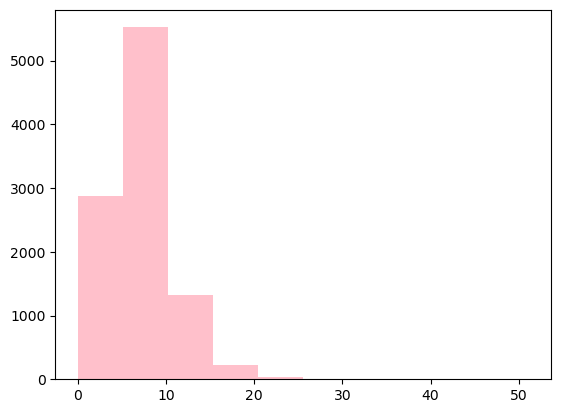

In [ ]:
plt.hist(x=data.DowntimeHours, color="pink")


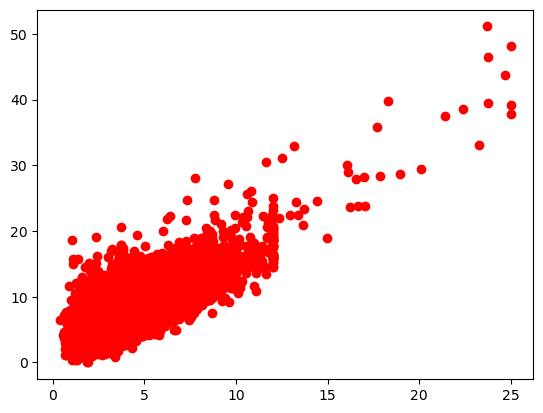

In [ ]:
plt.scatter(x=data.VibrationLevel, y=data.DowntimeHours, color="red")


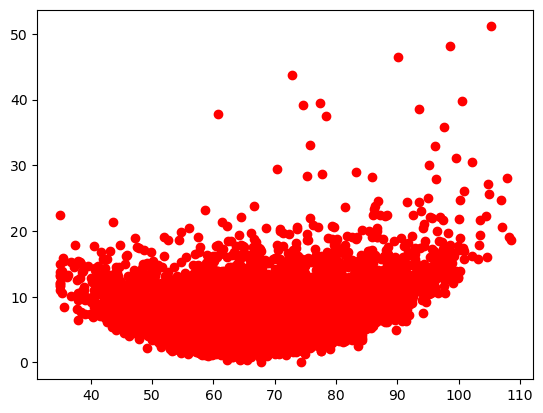

In [ ]:
plt.scatter(x=data.Temperature, y=data.DowntimeHours, color="red")


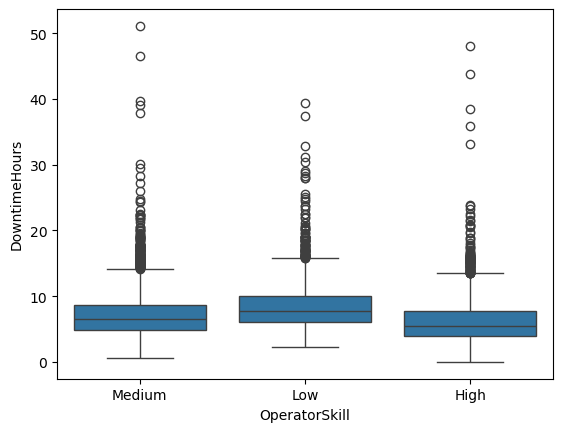

In [ ]:
sns.boxplot(data=data, x="OperatorSkill", y="DowntimeHours")
plt.show()


In [ ]:
numeric_cols = data.select_dtypes(include=["int64", "float64"])
numeric_cols


,Age,OperatingHours,Temperature,VibrationLevel,Pressure,MaintenanceHours,Failures,EnergyConsumption,DowntimeHours
0,8.2,435.0,49.8,2.002,8.15,1.5,3,1177.4,5.81
1,2.8,496.4,77.8,3.242,7.61,0.0,3,1352.9,6.96
2,10.0,294.9,67.4,1.694,10.00,4.3,0,1187.0,3.19
3,10.8,395.7,61.4,2.322,9.73,3.5,2,1160.0,4.18
4,0.0,490.5,65.2,2.939,6.16,2.9,0,1225.4,4.13
...,...,...,...,...,...,...,...,...,...
9995,13.5,570.0,70.4,1.996,9.93,2.5,2,1515.1,4.59
9996,6.7,351.0,70.1,1.919,12.24,0.0,0,1349.7,3.93
9997,7.3,474.5,88.5,7.123,10.10,1.8,5,1532.0,16.22
9998,11.5,465.1,72.2,2.106,11.54,0.5,1,1404.0,5.39


In [ ]:
categorical_cols = data.select_dtypes(include="object")
categorical_cols.head()


,MachineID,ShiftPattern,OperatorSkill
0,M100000,Day,Medium
1,M100001,Night,Medium
2,M100002,Rotational,Low
3,M100003,Night,High
4,M100004,Rotational,Medium


In [ ]:
correlation_matrix = numeric_cols.corr()


<Axes: >

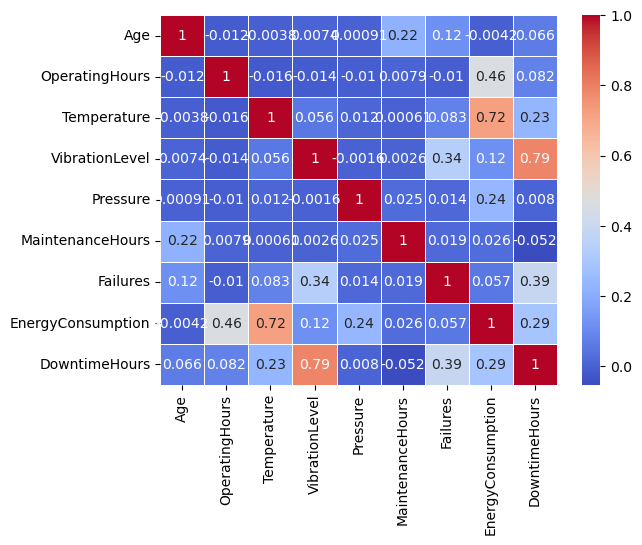

In [ ]:
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=0.5)


In [ ]:
def missing_imputation(df, columns):
    for col in columns:
        if df[col].isnull().sum():
            if df[col].dtypes == "int64" or df[col].dtypes == "float64":
                median = df[col].median()
                df[col].fillna(median, inplace=True)
            elif df[col].dtypes == "object":
                mode = df[col].mode()[0]
                df[col].fillna(mode, inplace=True)


missing_imputation(data, data.columns)


In [ ]:
data.isnull().sum()


MachineID            0
Age                  0
OperatingHours       0
Temperature          0
VibrationLevel       0
Pressure             0
MaintenanceHours     0
Failures             0
ShiftPattern         0
OperatorSkill        0
EnergyConsumption    0
DowntimeHours        0
dtype: int64

In [ ]:
y_target = data["DowntimeHours"]
X_features = data.drop(columns=["DowntimeHours", "MachineID"])


In [ ]:
dummy_var = pd.get_dummies(data=X_features, drop_first=True, dtype=int)


In [ ]:
dummy_var.head()


,Age,OperatingHours,Temperature,VibrationLevel,Pressure,MaintenanceHours,Failures,EnergyConsumption,ShiftPattern_Night,ShiftPattern_Rotational,OperatorSkill_Low,OperatorSkill_Medium
0,8.2,435.0,49.8,2.002,8.15,1.5,3,1177.4,0,0,0,1
1,2.8,496.4,77.8,3.242,7.61,0.0,3,1352.9,1,0,0,1
2,10.0,294.9,67.4,1.694,10.00,4.3,0,1187.0,0,1,1,0
3,10.8,395.7,61.4,2.322,9.73,3.5,2,1160.0,1,0,0,0
4,0.0,490.5,65.2,2.939,6.16,2.9,0,1225.4,0,1,0,1


In [ ]:
from sklearn.preprocessing import StandardScaler


In [ ]:
X_scaler = StandardScaler()
features_scale = X_scaler.fit_transform(dummy_var)
df_features_scale = pd.DataFrame(features_scale, columns=dummy_var.columns)
df_features_scale.head()


,Age,OperatingHours,Temperature,VibrationLevel,Pressure,MaintenanceHours,Failures,EnergyConsumption,ShiftPattern_Night,ShiftPattern_Rotational,OperatorSkill_Low,OperatorSkill_Medium
0,0.302371,0.155740,-1.686124,-0.846550,-0.891853,-0.220715,0.988083,-0.791072,-0.571654,-0.575195,-0.560565,0.983929
1,-1.091353,0.876335,0.861190,-0.263940,-1.256218,-1.258689,0.988083,0.303605,1.749311,-0.575195,-0.560565,0.983929
2,0.766945,-1.488483,-0.084956,-0.991263,0.356436,1.716837,-1.206357,-0.731192,-0.571654,1.738541,1.783914,-1.016333
3,0.973423,-0.305487,-0.630809,-0.696199,0.174253,1.163250,0.256603,-0.899604,1.749311,-0.575195,-0.560565,-1.016333
4,-1.814024,0.807092,-0.285102,-0.406304,-2.234606,0.748061,-1.206357,-0.491673,-0.571654,1.738541,-0.560565,0.983929


In [ ]:
y = (y_target - y_target.mean()) / y_target.std()
y.head()


0   -0.393704
1   -0.076244
2   -1.116962
3   -0.843670
4   -0.857473
Name: DowntimeHours, dtype: float64

In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df_features_scale, y, random_state=69, test_size=0.2
)
print("X_train", X_train.shape)
print("y_train", y_train.shape)

print("X_test", X_test.shape)
print("y_test", y_test.shape)


X_train (8000, 12)
y_train (8000,)
X_test (2000, 12)
y_test (2000,)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
def get_train_rmse(model):
    train_pred = model.predict(X_train)
    mse_train = mean_squared_error(y_train, train_pred)
    rmse_train = round(np.sqrt(mse_train), 4)
    return rmse_train


def get_test_rmse(model):
    test_pred = model.predict(X_test)
    mse_test = mean_squared_error(y_test, test_pred)
    rmse_test = round(np.sqrt(mse_test), 4)
    return rmse_test


def mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100


def get_test_mape(model):
    test_pred = model.predict(X_test)
    mape_test = mape(y_test, test_pred)
    return mape_test


def get_score(model):
    r_sq = model.score(X_train, y_train)
    n = X_train.shape[0]
    k = X_train.shape[1]
    r_sq_adj = 1 - ((1 - r_sq) * (n - 1) / (n - k - 1))
    return [r_sq, r_sq_adj]


In [ ]:
score_card = pd.DataFrame(
    columns=[
        "Model_Name",
        "Alpha (Wherever Required)",
        "l1-ratio",
        "R-Squared",
        "Adj. R-Squared",
        "Test_RMSE",
        "Test_MAPE",
    ]
)


def update_score_card(algorithm_name, model, alpha="-", l1_ratio="-"):
    global score_card
    new_row = pd.DataFrame(
        {
            "Model_Name": [algorithm_name],
            "Alpha (Wherever Required)": [alpha],
            "l1-ratio": [l1_ratio],
            "Test_MAPE": [get_test_mape(model)],
            "Test_RMSE": [get_test_rmse(model)],
            "R-Squared": [get_score(model)[0]],
            "Adj. R-Squared": [get_score(model)[1]],
        }
    )
    score_card = pd.concat([score_card, new_row], ignore_index=True)
    return score_card


In [ ]:
def plot_coefficients(model, algorithm_name):
    df_coeff = pd.DataFrame({"Variable": X_train.columns, "Coefficient": model.coef_})
    sorted_coeff = df_coeff.sort_values("Coefficient", ascending=False)
    sns.barplot(x="Coefficient", y="Variable", data=sorted_coeff)
    plt.xlabel("Coefficients from {}".format(algorithm_name), fontsize=15)
    plt.ylabel("Features", fontsize=15)


# Linear Regression

In [ ]:
linear_reg = LinearRegression()
MLR_model = linear_reg.fit(X_train, y_train)
MLR_model.score(X_train, y_train)


0.7451903998673703

In [ ]:
print("RMSE on train set: ", get_train_rmse(MLR_model))

print("RMSE on test set: ", get_test_rmse(MLR_model))

difference = abs(get_test_rmse(MLR_model) - get_train_rmse(MLR_model))

print("Difference between RMSE on train and test set: ", difference)


RMSE on train set:  0.5066
RMSE on test set:  0.4942
Difference between RMSE on train and test set:  0.012400000000000078


In [ ]:
score_card = update_score_card(algorithm_name="linearRegression", model=MLR_model)
score_card


,Model_Name,Alpha (Wherever Required),l1-ratio,R-Squared,Adj. R-Squared,Test_RMSE,Test_MAPE
0,linearRegression,-,-,0.74519,0.744808,0.4942,226.087941


# Stochastic Gradient Descent

In [ ]:
from sklearn.linear_model import SGDRegressor


In [ ]:
sgd = SGDRegressor()
linreg_with_SGD = sgd.fit(X_train, y_train)
print("RMSE on train set:", get_train_rmse(linreg_with_SGD))
print("RMSE on test set:", get_test_rmse(linreg_with_SGD))


RMSE on train set: 0.507
RMSE on test set: 0.4951


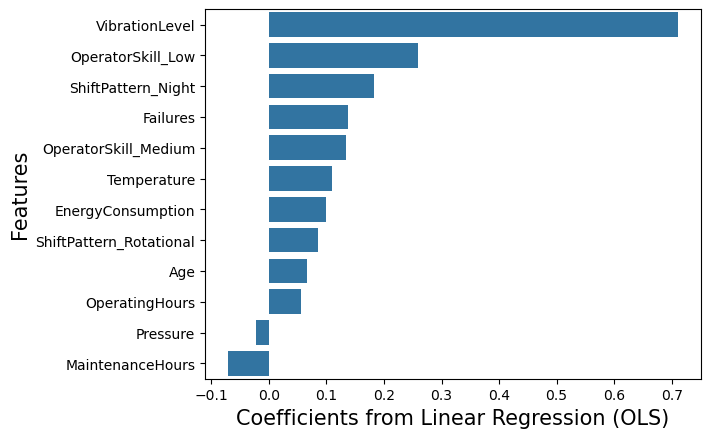

In [ ]:
plot_coefficients(MLR_model, "Linear Regression (OLS)")


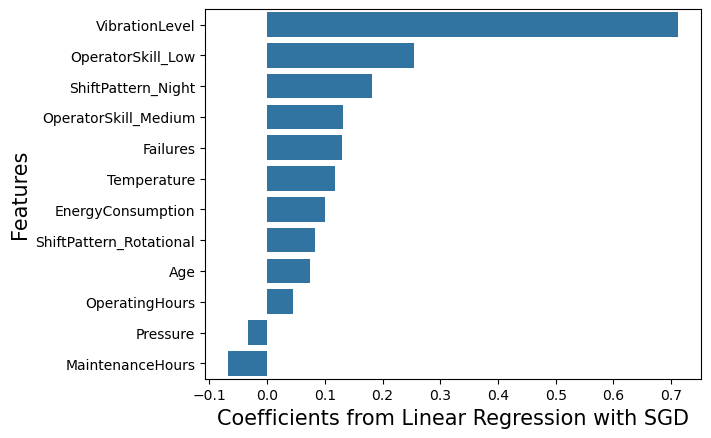

In [ ]:
plot_coefficients(linreg_with_SGD, "Linear Regression with SGD")


In [ ]:
score_card = update_score_card(
    algorithm_name="linearRegression with SGD", model=linreg_with_SGD
)
score_card


,Model_Name,Alpha (Wherever Required),l1-ratio,R-Squared,Adj. R-Squared,Test_RMSE,Test_MAPE
0,linearRegression,-,-,0.745190,0.744808,0.4942,226.087941
1,linearRegression with SGD,-,-,0.744758,0.744375,0.4951,223.521223


## Regularization

- ### Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge


In [ ]:
ridge = Ridge(alpha=1.0, max_iter=500)
ridge.fit(X_train, y_train)


Ridge(max_iter=500)

In [ ]:
score_card = update_score_card(
    model=ridge, algorithm_name="Ridge Regression", alpha=1.0
)
score_card


,Model_Name,Alpha (Wherever Required),l1-ratio,R-Squared,Adj. R-Squared,Test_RMSE,Test_MAPE
0,linearRegression,-,-,0.745190,0.744808,0.4942,226.087941
1,linearRegression with SGD,-,-,0.744758,0.744375,0.4951,223.521223
2,Ridge Regression,1.0,-,0.745190,0.744808,0.4942,226.064187


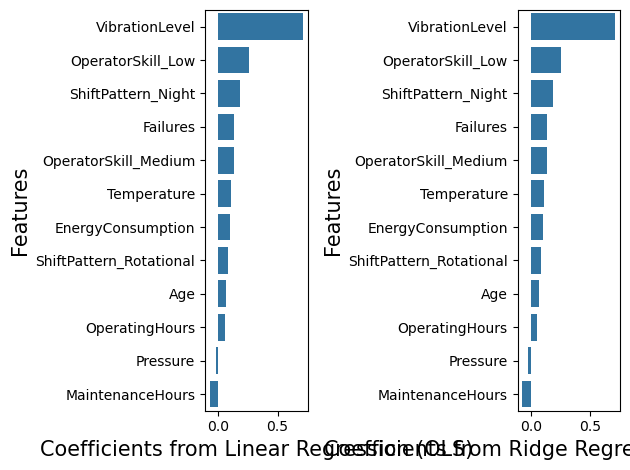

In [ ]:
plt.subplot(1, 2, 1)
plot_coefficients(linear_reg, "Linear Regression (OLS)")
plt.subplot(1, 2, 2)
plot_coefficients(ridge, "Ridge Regression (alpha = 2)")
plt.tight_layout()
plt.show()


- ### Lasso Regression

In [ ]:
from sklearn.linear_model import Lasso


In [ ]:
lasso = Lasso(alpha=0.01, max_iter=500)
lasso.fit(X_train, y_train)


Lasso(alpha=0.01, max_iter=500)

In [ ]:
score_card = update_score_card(
    model=lasso, algorithm_name="Lasso Regression", alpha=0.01
)
score_card


,Model_Name,Alpha (Wherever Required),l1-ratio,R-Squared,Adj. R-Squared,Test_RMSE,Test_MAPE
0,linearRegression,-,-,0.745190,0.744808,0.4942,226.087941
1,linearRegression with SGD,-,-,0.744758,0.744375,0.4951,223.521223
2,Ridge Regression,1.0,-,0.745190,0.744808,0.4942,226.064187
3,Lasso Regression,0.01,-,0.743722,0.743336,0.4956,222.350108


In [ ]:
df_lasso_coeff = pd.DataFrame(
    {"Variable": df_features_scale.columns, "Coefficient": lasso.coef_}
)

print("Insignificant variables obtained from Lasso Regression when alpha is 0.01")
df_lasso_coeff.Variable[df_lasso_coeff.Coefficient == 0].to_list()


Insignificant variables obtained from Lasso Regression when alpha is 0.01


[]

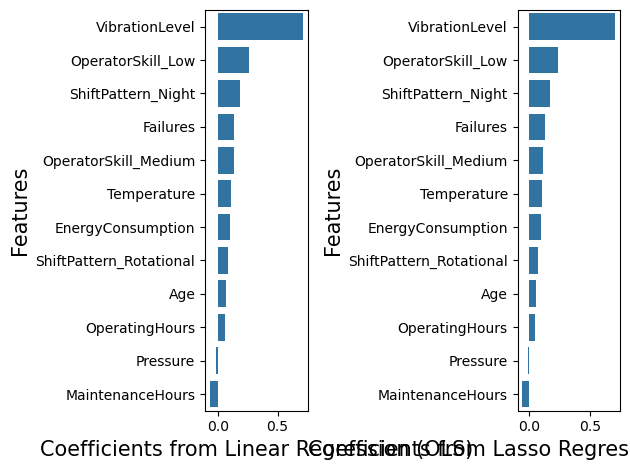

In [ ]:
plt.subplot(1, 2, 1)
plot_coefficients(linear_reg, "Linear Regression (OLS)")
plt.subplot(1, 2, 2)
plot_coefficients(lasso, "Lasso Regression (alpha = 0.01)")
plt.tight_layout()
plt.show()


- ### Elastic Net Regression

In [44]:
from sklearn.linear_model import ElasticNet


In [ ]:
enet = ElasticNet(alpha=0.1, l1_ratio=0.01, max_iter=500)
enet.fit(X_train, y_train)


ElasticNet(alpha=0.1, l1_ratio=0.01, max_iter=500)

In [ ]:
score_card = update_score_card(
    model=enet, algorithm_name="Elastic Net Regression", alpha=0.1, l1_ratio=0.01
)
score_card


,Model_Name,Alpha (Wherever Required),l1-ratio,R-Squared,Adj. R-Squared,Test_RMSE,Test_MAPE
0,linearRegression,-,-,0.745190,0.744808,0.4942,226.087941
1,linearRegression with SGD,-,-,0.744758,0.744375,0.4951,223.521223
2,Ridge Regression,1.0,-,0.745190,0.744808,0.4942,226.064187
3,Lasso Regression,0.01,-,0.743722,0.743336,0.4956,222.350108
4,Elastic Net Regression,0.1,0.01,0.738914,0.738522,0.4999,209.700832


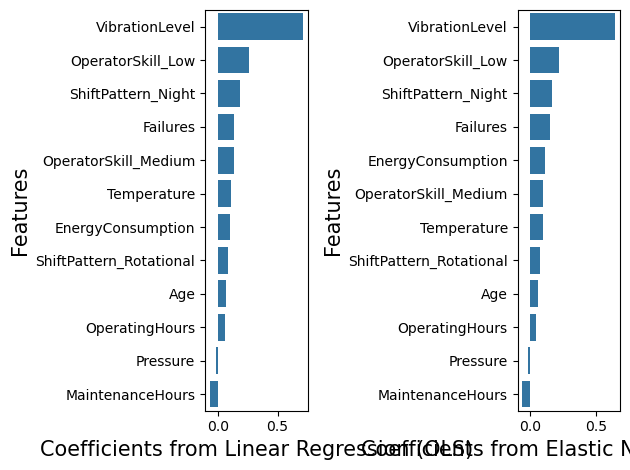

In [ ]:
plt.subplot(1, 2, 1)
plot_coefficients(MLR_model, "Linear Regression (OLS)")
plt.subplot(1, 2, 2)
plot_coefficients(enet, "Elastic Net Regression")
plt.tight_layout()

plt.show()


# Tuning Hyperparameters    

- ## Grid Search CV using Ridge Regression

In [ ]:
from sklearn.model_selection import GridSearchCV


In [ ]:
tuned_paramaters = [
    {
        "alpha": [
            1e-15,
            1e-10,
            1e-8,
            1e-4,
            1e-3,
            1e-2,
            0.1,
            1,
            5,
            10,
            20,
            40,
            60,
            80,
            100,
        ]
    }
]

ridge = Ridge()
ridge_grid = GridSearchCV(estimator=ridge, param_grid=tuned_paramaters, cv=10)

ridge_grid.fit(X_train, y_train)


GridSearchCV(cv=10, estimator=Ridge(),
             param_grid=[{'alpha': [1e-15, 1e-10, 1e-08, 0.0001, 0.001, 0.01,
                                    0.1, 1, 5, 10, 20, 40, 60, 80, 100]}])

In [ ]:
update_score_card(
    algorithm_name="Ridge Regression (using GridSearchCV)",
    model=ridge_grid,
    alpha=ridge_grid.best_params_.get("alpha"),
)

score_card


,Model_Name,Alpha (Wherever Required),l1-ratio,R-Squared,Adj. R-Squared,Test_RMSE,Test_MAPE
0,linearRegression,-,-,0.745190,0.744808,0.4942,226.087941
1,linearRegression with SGD,-,-,0.744758,0.744375,0.4951,223.521223
2,Ridge Regression,1.0,-,0.745190,0.744808,0.4942,226.064187
3,Lasso Regression,0.01,-,0.743722,0.743336,0.4956,222.350108
4,Elastic Net Regression,0.1,0.01,0.738914,0.738522,0.4999,209.700832
5,Ridge Regression (using GridSearchCV),20,-,0.745185,0.744803,0.4941,225.614979


## Grid Search CV using Lasso Regression

In [ ]:
tuned_paramaters = [
    {"alpha": [1e-15, 1e-10, 1e-8, 0.0001, 0.001, 0.01, 0.1, 1, 5, 10, 20]}
]

lasso = Lasso()

lasso_grid = GridSearchCV(estimator=lasso, param_grid=tuned_paramaters, cv=10)

lasso_grid.fit(X_train, y_train)


GridSearchCV(cv=10, estimator=Lasso(),
             param_grid=[{'alpha': [1e-15, 1e-10, 1e-08, 0.0001, 0.001, 0.01,
                                    0.1, 1, 5, 10, 20]}])

In [ ]:
update_score_card(
    algorithm_name="Lasso Regression (using GridSearchCV)",
    model=lasso_grid,
    alpha=lasso_grid.best_params_.get("alpha"),
)

score_card


,Model_Name,Alpha (Wherever Required),l1-ratio,R-Squared,Adj. R-Squared,Test_RMSE,Test_MAPE
0,linearRegression,-,-,0.745190,0.744808,0.4942,226.087941
1,linearRegression with SGD,-,-,0.744758,0.744375,0.4951,223.521223
2,Ridge Regression,1.0,-,0.745190,0.744808,0.4942,226.064187
3,Lasso Regression,0.01,-,0.743722,0.743336,0.4956,222.350108
4,Elastic Net Regression,0.1,0.01,0.738914,0.738522,0.4999,209.700832
5,Ridge Regression (using GridSearchCV),20,-,0.745185,0.744803,0.4941,225.614979
6,Lasso Regression (using GridSearchCV),0.0001,-,0.745190,0.744807,0.4942,226.048750


## Grid Search CV using Elastic Net Regression

In [ ]:
tuned_paramaters = [
    {
        "alpha": [0.0001, 0.001, 0.01, 0.1, 1, 5, 10, 20, 40, 60],
        "l1_ratio": [0.0001, 0.0002, 0.001, 0.01, 0.1, 0.2],
    }
]

enet = ElasticNet()

enet_grid = GridSearchCV(estimator=enet, param_grid=tuned_paramaters, cv=10)
enet_grid.fit(X_train, y_train)


GridSearchCV(cv=10, estimator=ElasticNet(),
             param_grid=[{'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 5, 10, 20, 40,
                                    60],
                          'l1_ratio': [0.0001, 0.0002, 0.001, 0.01, 0.1, 0.2]}])

In [ ]:
update_score_card(
    algorithm_name="Elastic Net Regression (using GridSearchCV)",
    model=enet_grid,
    alpha=enet_grid.best_params_.get("alpha"),
    l1_ratio=enet_grid.best_params_.get("l1_ratio"),
)

score_card


,Model_Name,Alpha (Wherever Required),l1-ratio,R-Squared,Adj. R-Squared,Test_RMSE,Test_MAPE
0,linearRegression,-,-,0.745190,0.744808,0.4942,226.087941
1,linearRegression with SGD,-,-,0.744758,0.744375,0.4951,223.521223
2,Ridge Regression,1.0,-,0.745190,0.744808,0.4942,226.064187
3,Lasso Regression,0.01,-,0.743722,0.743336,0.4956,222.350108
4,Elastic Net Regression,0.1,0.01,0.738914,0.738522,0.4999,209.700832
5,Ridge Regression (using GridSearchCV),20,-,0.745185,0.744803,0.4941,225.614979
6,Lasso Regression (using GridSearchCV),0.0001,-,0.745190,0.744807,0.4942,226.048750
7,Elastic Net Regression (using GridSearchCV),0.001,0.0001,0.745190,0.744807,0.4942,225.898249


# Model Comparison

In [ ]:
score_card = score_card.sort_values("Test_RMSE").reset_index(drop=True)

score_card.style.highlight_min(color="lightblue", subset="Test_RMSE")


,Model_Name,Alpha (Wherever Required),l1-ratio,R-Squared,Adj. R-Squared,Test_RMSE,Test_MAPE
0,Ridge Regression (using GridSearchCV),20,-,0.745185,0.744803,0.494100,225.614979
1,linearRegression,-,-,0.745190,0.744808,0.494200,226.087941
2,Lasso Regression (using GridSearchCV),0.000100,-,0.745190,0.744807,0.494200,226.048750
3,Ridge Regression,1.000000,-,0.745190,0.744808,0.494200,226.064187
4,Elastic Net Regression (using GridSearchCV),0.001000,0.000100,0.745190,0.744807,0.494200,225.898249
5,linearRegression with SGD,-,-,0.744758,0.744375,0.495100,223.521223
6,Lasso Regression,0.010000,-,0.743722,0.743336,0.495600,222.350108
7,Elastic Net Regression,0.100000,0.010000,0.738914,0.738522,0.499900,209.700832
